# Adquisición e Inspección de Datos
Este notebook se encarga de cargar la configuración del dataset de cromosomas y visualizar ejemplos de las imágenes disponibles **junto con sus anotaciones (bounding boxes)**.

In [6]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
import random

## 1. Definición de Rutas y Carga de Configuración
Inspeccionamos la carpeta `data/raw/chromosoma-1` para leer el archivo `data.yaml` y contabilizar las imágenes.

In [7]:
# Ajustar la ruta asumiendo que el notebook se ejecuta desde la carpeta scripts/data_acquisition
data_path = Path('../../data/raw/chromosoma-1')
yaml_file = data_path / 'data.yaml'
class_names = []

if not data_path.exists():
    print(f'Error: El directorio {data_path} no existe. Verifica la ruta.')
else:
    config = {}
    with open(yaml_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        in_names = False
        for line in lines:
            line = line.strip()
            if line.startswith('nc:'):
                config['nc'] = int(line.split(':')[1].strip())
            elif line.startswith('names:'):
                in_names = True
            elif in_names and line.startswith('-'):
                class_names.append(line.replace('-', '').strip())
            elif in_names and ':' in line:
                in_names = False
        config['names'] = class_names
        
    print('--- Resumen del Dataset ---')
    print(f'Número de clases: {config.get("nc")}')
    print(f'Clases: {config.get("names")}')
    
    # Contar imágenes
    splits = ['train', 'valid', 'test']
    for split in splits:
        split_dir = data_path / split / 'images'
        if split_dir.exists():
            num_images = len(list(split_dir.glob('*.jpg')))
            print(f'Imágenes en conjunto de {split}: {num_images}')
        else:
            print(f'Conjunto de {split} no encontrado en {split_dir}')


--- Resumen del Dataset ---
Número de clases: 24
Clases: ['A1', 'A2', 'A3', 'B4', 'B5', 'C10', 'C11', 'C12', 'C6', 'C7', 'C8', 'C9', 'D13', 'D14', 'D15', 'E16', 'E17', 'E18', 'F19', 'F20', 'G21', 'G22', 'X', 'Y']
Imágenes en conjunto de train: 2995
Imágenes en conjunto de valid: 999
Imágenes en conjunto de test: 1000


## 2. Visualización de Ejemplos con Anotaciones (Bounding Boxes)
Seleccionamos 4 imágenes al azar del conjunto de entrenamiento y le superponemos sus respectivas etiquetas de cromosomas.

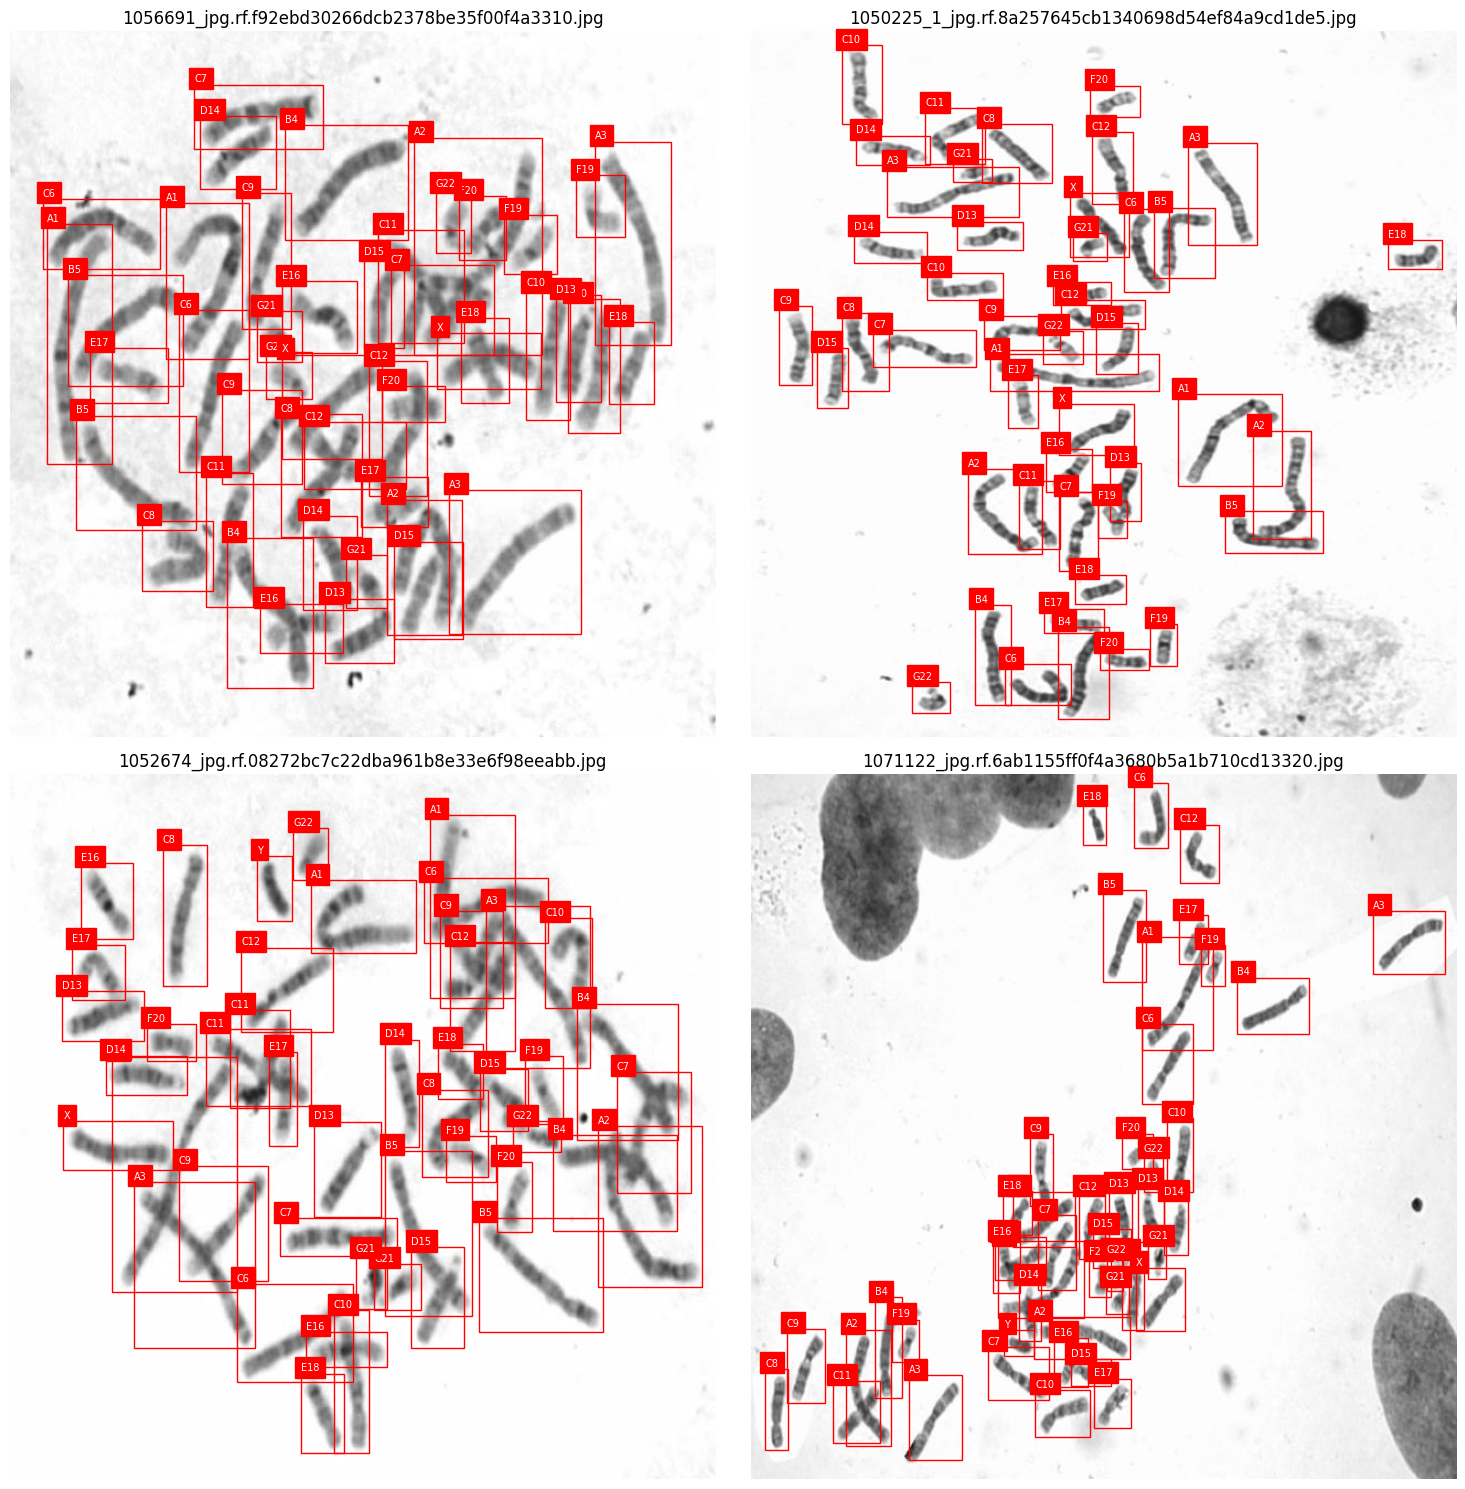

In [8]:
def draw_bboxes(img_path, ax, class_names):
    img = mpimg.imread(str(img_path))
    h, w, _ = img.shape
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(img_path.name)
    
    # Buscar el archivo .txt correspondiente a la imagen
    label_path = img_path.parent.parent / 'labels' / f"{img_path.stem}.txt"
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id, x_center, y_center, width, height = map(float, parts)
                    cls_id = int(cls_id)
                    
                    # Desnormalizar coordenadas (formato YOLO)
                    x_center *= w
                    y_center *= h
                    width *= w
                    height *= h
                    
                    # Convertir a coordenadas para matplotlib (esquina inferior izquierda)
                    x_min = x_center - width / 2
                    y_min = y_center - height / 2
                    
                    # Dibujar rectángulo
                    rect = patches.Rectangle((x_min, y_min), width, height, linewidth=1, edgecolor='red', facecolor='none')
                    ax.add_patch(rect)
                    
                    # Añadir etiqueta de la clase
                    class_name = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
                    ax.text(x_min, y_min - 3, class_name, color='white', fontsize=7, backgroundcolor='red')

train_images_dir = data_path / 'train' / 'images'
if train_images_dir.exists():
    all_images = list(train_images_dir.glob('*.jpg'))
    if len(all_images) >= 4:
        sample_images = random.sample(all_images, 4)
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 15))
        axes = axes.flatten()
        
        for ax, img_path in zip(axes, sample_images):
            draw_bboxes(img_path, ax, class_names)
            
        plt.tight_layout()
        plt.show()
    else:
        print('No hay suficientes imágenes para mostrar.')
else:
    print(f'Directorio no encontrado: {train_images_dir}')
